In [150]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [151]:
df = pd.read_csv('/Users/fuyanting/Documents/capstone/data/df.csv')
df_map = pd.read_csv('/Users/fuyanting/Documents/capstone/data/df_map.csv')

In [152]:
print("df dtypes:")
print(df.dtypes)
print("\n-----------------\n")
print("df_map dtypes:")
print(df_map.dtypes)

df dtypes:
ID                        int64
Date                     object
Primary Type             object
Description              object
Location Description     object
Arrest                     bool
Domestic                   bool
District                  int64
Community Area            int64
Year                      int64
Latitude                float64
Longitude               float64
Month                     int64
Hour                      int64
DayOfWeek                 int64
dtype: object

-----------------

df_map dtypes:
ID                        int64
Date                     object
Primary Type             object
Description              object
Location Description     object
Arrest                     bool
Domestic                   bool
District                float64
Community Area          float64
Year                      int64
Latitude                float64
Longitude               float64
Month                     int64
Hour                      int64
DayOfWeek   

In [153]:

def fix_dtypes(data):
    data = data.copy()

    # datetime
    data['Date'] = pd.to_datetime(data['Date'], errors='coerce')

    # integer-like columns with possible missing values
    int_cols = ['ID', 'District', 'Community Area', 'Year', 'Month', 'Hour', 'DayOfWeek']
    for col in int_cols:
        if col in data.columns:
            data[col] = pd.to_numeric(data[col], errors='coerce').astype('Int32')

    # float columns
    float_cols = ['Latitude', 'Longitude']
    for col in float_cols:
        if col in data.columns:
            data[col] = pd.to_numeric(data[col], errors='coerce').astype('float32')

    # boolean columns
    bool_cols = ['Arrest', 'Domestic']
    for col in bool_cols:
        if col in data.columns:
            data[col] = data[col].astype('boolean')

    # category columns
    cat_cols = ['Primary Type', 'Description', 'Location Description']
    for col in cat_cols:
        if col in data.columns:
            data[col] = data[col].astype('category')

    return data

df = fix_dtypes(df)
df_map = fix_dtypes(df_map)

/var/folders/y4/3yldd68d36qfw_vh1kk8kp5m0000gn/T/ipykernel_84683/3264648823.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Date'] = pd.to_datetime(data['Date'], errors='coerce')


In [154]:
print("df dtypes after fixing:")
print(df.dtypes)

print("\n-----------------\n")

print("df_map dtypes after fixing:")
print(df_map.dtypes)

df dtypes after fixing:
ID                               Int32
Date                    datetime64[ns]
Primary Type                  category
Description                   category
Location Description          category
Arrest                         boolean
Domestic                       boolean
District                         Int32
Community Area                   Int32
Year                             Int32
Latitude                       float32
Longitude                      float32
Month                            Int32
Hour                             Int32
DayOfWeek                        Int32
dtype: object

-----------------

df_map dtypes after fixing:
ID                               Int32
Date                    datetime64[ns]
Primary Type                  category
Description                   category
Location Description          category
Arrest                         boolean
Domestic                       boolean
District                         Int32
Community Area   

## 1. Dataset Overview

1. Dataset Overview
	1.	数据来源 & 时间范围
	2.	数据规模
	3.	变量结构（按类别讲）
	4.	数据清理与处理

This dataset contains reported crime incidents in Chicago.
The analysis focuses on data from 2016 to 2025 to capture recent trends while maintaining a sufficiently large sample size.
The dataset contains approximately X million records, with each year contributing several hundred thousand observations.
The dataset includes temporal variables, crime type classifications, geographic information, and outcome indicators such as arrest status.
preprocessing:列筛选,时间变量处理,缺失值处理,重复值检查

## 2. Overall Crime Patterns
How did Crimes distribute across time, types, and locations.

   Year  Crime Count
0  2016       269951
1  2017       269276
2  2018       269133
3  2019       261693
4  2020       212697
5  2021       209632
6  2022       240003
7  2023       263292
8  2024       259066
9  2025       236925


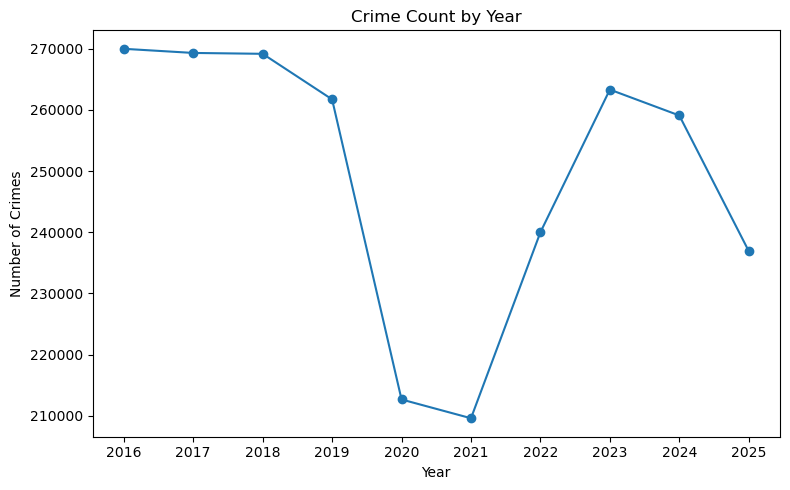

In [155]:
# Time
#Year
year_counts = df.groupby('Year').size().reset_index(name='Crime Count')
print(year_counts)

plt.figure(figsize=(8, 5))
plt.plot(year_counts['Year'], year_counts['Crime Count'], marker='o')
plt.title('Crime Count by Year')
plt.xlabel('Year')
plt.ylabel('Number of Crimes')
plt.xticks(year_counts['Year'])
plt.tight_layout()
plt.show()

The overall crime trend shows a relatively stable level from 2016 to 2018, followed by a noticeable decline starting in 2019.
A sharp drop is observed in 2020 and 2021, after which crime levels rebound significantly in 2022 and 2023. This sharp decline during 2020–2021 is consistent with the impact of COVID-19, which significantly altered social activity patterns.

    Month  Crime Count
0       1       195110
1       2       175555
2       3       197350
3       4       192793
4       5       216916
5       6       220460
6       7       232095
7       8       229200
8       9       217882
9      10       219053
10     11       198559
11     12       196695


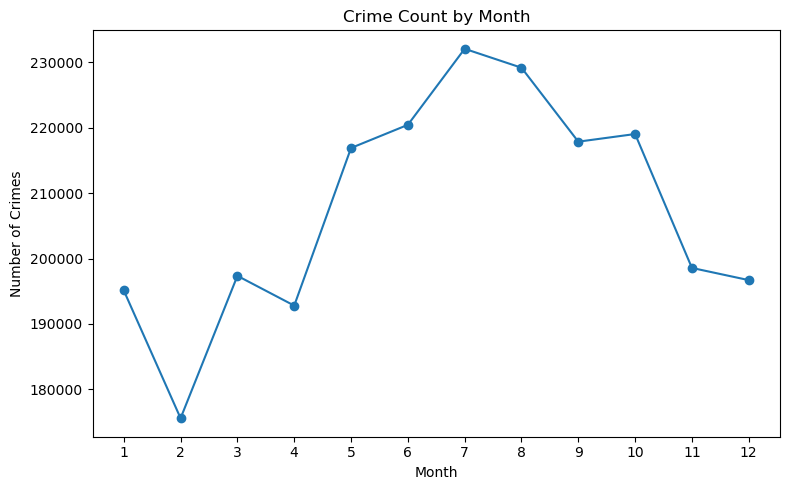

    Month  Average Crime Count
0       1              19511.0
1       2              17555.5
2       3              19735.0
3       4              19279.3
4       5              21691.6
5       6              22046.0
6       7              23209.5
7       8              22920.0
8       9              21788.2
9      10              21905.3
10     11              19855.9
11     12              19669.5


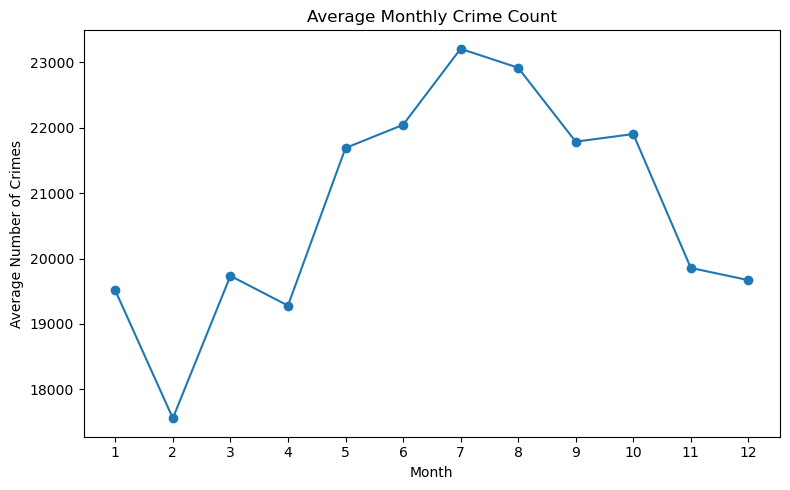

In [156]:
#Month
month_counts = df.groupby('Month').size().reset_index(name='Crime Count')
print(month_counts)

plt.figure(figsize=(8, 5))
plt.plot(month_counts['Month'], month_counts['Crime Count'], marker='o')
plt.title('Crime Count by Month')
plt.xlabel('Month')
plt.ylabel('Number of Crimes')
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()


monthly_by_year = df.groupby(['Year', 'Month']).size().reset_index(name='Crime Count')
monthly_avg = monthly_by_year.groupby('Month')['Crime Count'].mean().reset_index(name='Average Crime Count')
print(monthly_avg)

plt.figure(figsize=(8, 5))
plt.plot(monthly_avg['Month'], monthly_avg['Average Crime Count'], marker='o')
plt.title('Average Monthly Crime Count')
plt.xlabel('Month')
plt.ylabel('Average Number of Crimes')
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

Crime incidents exhibit a clear seasonal pattern. The lowest levels are observed in winter months, particularly February, while crime increases steadily from spring and peaks during the summer months, especially in July and August. After the peak, crime levels gradually decline toward the end of the year. This pattern suggests that crime is positively associated with warmer weather and increased outdoor activity. The average monthly crime pattern closely mirrors the overall monthly distribution, confirming that the seasonal trend is consistent across years rather than driven by anomalies in specific periods.

    Hour  Crime Count
0      0       155805
1      1        78672
2      2        68617
3      3        57755
4      4        46609
5      5        40686
6      6        45181
7      7        61069
8      8        85860
9      9       110613
10    10       110369
11    11       112265
12    12       148226
13    13       116942
14    14       122664
15    15       134746
16    16       132089
17    17       134340
18    18       135886
19    19       133246
20    20       127672
21    21       117926
22    22       114368
23    23       100062


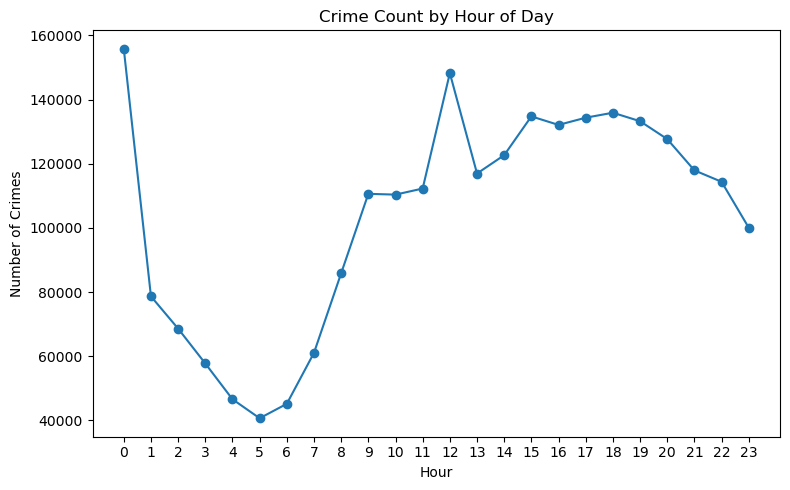

In [157]:
#Hour
hour_counts = df.groupby('Hour').size().reset_index(name='Crime Count')
print(hour_counts)

plt.figure(figsize=(8, 5))
plt.plot(hour_counts['Hour'], hour_counts['Crime Count'], marker='o')
plt.title('Crime Count by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Number of Crimes')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()


In [158]:
df['Date'].dt.minute.value_counts()

Date
0     841767
30    335895
45    105656
15     97788
20     75901
50     73163
40     71048
10     58512
25     40500
35     39326
5      39169
55     37494
1      35658
18     15288
58     15155
8      15118
38     15069
48     14948
12     14704
28     14653
47     14348
17     14234
23     14230
22     14207
7      14166
42     14034
43     14026
24     13927
53     13913
37     13893
13     13884
14     13859
27     13831
3      13725
57     13721
9      13613
52     13571
2      13505
36     13488
4      13485
26     13448
33     13427
44     13302
19     13244
54     13219
11     13191
56     13144
39     13096
32     13055
6      13029
16     12979
46     12953
34     12931
59     12859
49     12793
21     12717
29     12378
51     12171
41     11931
31     11329
Name: count, dtype: int64

In [159]:

df.groupby('Hour')['Primary Type'].value_counts().loc[0]

Primary Type
THEFT                                26841
BATTERY                              25465
DECEPTIVE PRACTICE                   23813
CRIMINAL DAMAGE                      19074
OTHER OFFENSE                        10389
MOTOR VEHICLE THEFT                   9635
ASSAULT                               8099
BURGLARY                              5840
ROBBERY                               4889
OFFENSE INVOLVING CHILDREN            4879
WEAPONS VIOLATION                     4800
NARCOTICS                             2296
CRIMINAL SEXUAL ASSAULT               2229
CRIMINAL TRESPASS                     2218
SEX OFFENSE                           1869
CRIM SEXUAL ASSAULT                    760
PUBLIC PEACE VIOLATION                 523
INTERFERENCE WITH PUBLIC OFFICER       464
HOMICIDE                               382
STALKING                               357
ARSON                                  343
PROSTITUTION                           130
LIQUOR LAW VIOLATION                   11

Crime incidents show a clear daily pattern, with lower levels during early morning hours and higher levels during daytime and evening.
However, an unusually high concentration of incidents at midnight suggests that timestamp accuracy may be influenced by reporting practices.
This is further supported by the high frequency of records with minute values equal to zero and the distribution of crime types at hour 0, which are not strongly tied to specific times of day.
Therefore, the observed midnight peak should be interpreted with caution.

  DayName  Crime Count
0     Mon       356112
1     Tue       350160
2     Wed       351983
3     Thu       349319
4     Fri       369755
5     Sat       362076
6     Sun       352263


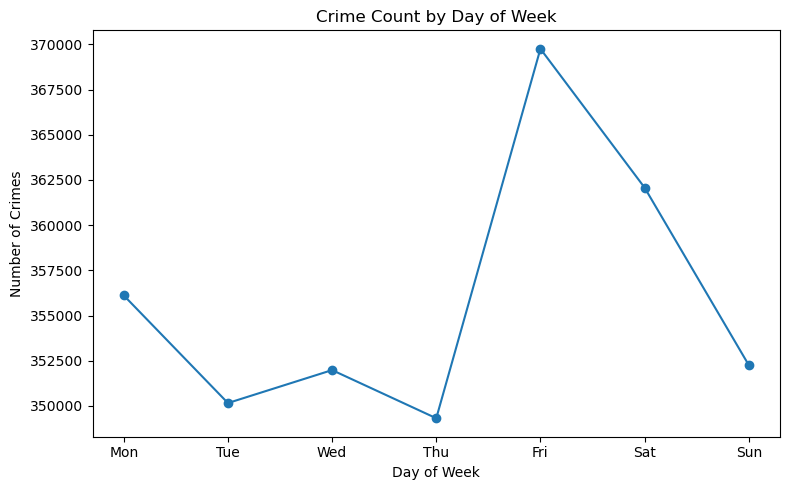

In [160]:
# Day of Week
day_map = {
    0: 'Mon',
    1: 'Tue',
    2: 'Wed',
    3: 'Thu',
    4: 'Fri',
    5: 'Sat',
    6: 'Sun'
}

df['DayName'] = df['DayOfWeek'].map(day_map)
day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

day_counts = (
    df.groupby('DayName')
      .size()
      .reindex(day_order)
      .reset_index(name='Crime Count')
)

print(day_counts)

plt.figure(figsize=(8, 5))
plt.plot(day_counts['DayName'], day_counts['Crime Count'], marker='o')
plt.title('Crime Count by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Crimes')
plt.tight_layout()
plt.show()

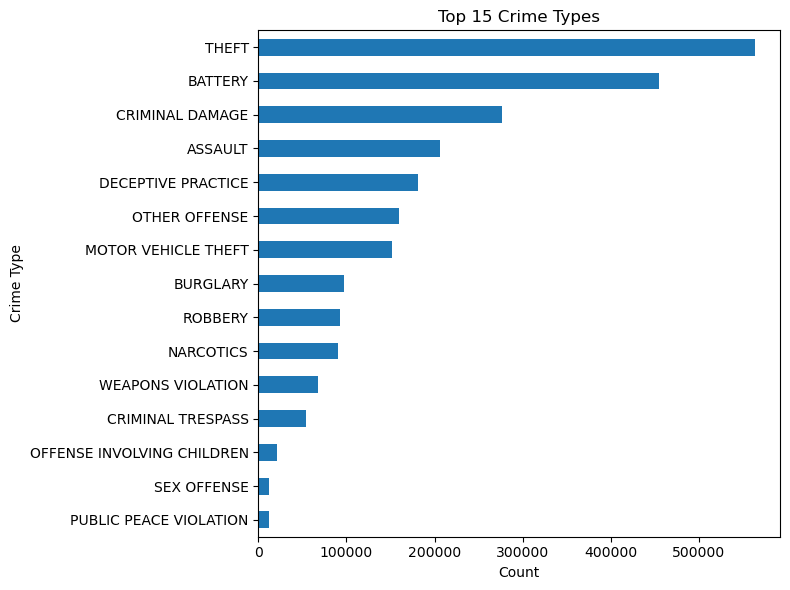

In [161]:
# Crimes by type

top15 = df['Primary Type'].value_counts().head(15)

top15.sort_values().plot(kind='barh', figsize=(8,6))
plt.title('Top 15 Crime Types')
plt.xlabel('Count')
plt.ylabel('Crime Type')
plt.tight_layout()
plt.show()

Crime distribution varies across the week, with the highest levels observed on Fridays and Saturdays.
Weekdays (Monday to Thursday) show relatively stable and lower crime levels, while Sunday falls between weekdays and peak weekend days.
This pattern indicates that crime tends to increase toward the weekend, potentially reflecting increased social activity and mobility.

Overall, crime incidents in Chicago exhibit clear temporal patterns across multiple time scales.
At the yearly level, crime remains relatively stable before a sharp decline in 2020–2021, followed by a strong recovery, suggesting a significant disruption and subsequent normalization over time.
Monthly patterns reveal strong seasonality, with crime peaking during summer months and reaching lower levels in winter, indicating a possible association with weather conditions and outdoor activity.
Within a day, crime levels are lowest during early morning hours and increase throughout the day, remaining relatively high during the afternoon and evening. Crime also tends to rise toward the weekend, with the highest levels observed on Fridays and Saturdays.

However, it is important to interpret the hourly pattern with caution. A disproportionately large number of incidents are recorded at exact hour marks (minute = 0), suggesting that timestamps may not always be precisely recorded and may involve rounding or default assignment. As a result, the observed peak at midnight may partly reflect data recording practices rather than actual crime concentration.

Taken together, these findings indicate that crime patterns are strongly aligned with human activity cycles, while also highlighting potential limitations in timestamp precision within the dataset.

## 3 Arrest Patterns

What factors are associated with differences in arrest outcomes?

### 3.1 Overall Arrest Rate

In [162]:
# Overall Arrest Rate
overall_arrest_rate = df['Arrest'].mean()
print("Overall arrest rate:", overall_arrest_rate)
print("Overall arrest rate (%):", round(overall_arrest_rate * 100, 2))

Overall arrest rate: 0.16495094852123157
Overall arrest rate (%): 16.5


### 3.2 Arrest Patterns by Crime Type

In [163]:
# Arrest by Crime Type
arrest_by_type = (
    df.groupby('Primary Type')
      .agg(
          crime_count=('Arrest', 'size'),
          arrest_rate=('Arrest', 'mean')
      )
      .reset_index()
      .sort_values(by='arrest_rate', ascending=False)
)

print(arrest_by_type)

                         Primary Type  crime_count  arrest_rate
10                           GAMBLING          820     0.996341
18                          NARCOTICS        90219     0.989625
24                       PROSTITUTION         4294     0.989054
16               LIQUOR LAW VIOLATION         2030     0.984236
4   CONCEALED CARRY LICENSE VIOLATION         1647     0.969035
25                   PUBLIC INDECENCY           88     0.965909
13   INTERFERENCE WITH PUBLIC OFFICER         8429     0.928224
20                          OBSCENITY          598     0.680602
32                  WEAPONS VIOLATION        68016      0.65689
26             PUBLIC PEACE VIOLATION        11480     0.561063
22           OTHER NARCOTIC VIOLATION           56     0.553571
8                   CRIMINAL TRESPASS        53642     0.442265
11                           HOMICIDE         6583     0.397843
19                       NON-CRIMINAL           25         0.32
2                             BATTERY   

/var/folders/y4/3yldd68d36qfw_vh1kk8kp5m0000gn/T/ipykernel_84683/4152149131.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Primary Type')


In [164]:
arrest_by_type_filtered = arrest_by_type[arrest_by_type['crime_count'] >= 1000]
print(arrest_by_type_filtered)

                         Primary Type  crime_count  arrest_rate
18                          NARCOTICS        90219     0.989625
24                       PROSTITUTION         4294     0.989054
16               LIQUOR LAW VIOLATION         2030     0.984236
4   CONCEALED CARRY LICENSE VIOLATION         1647     0.969035
13   INTERFERENCE WITH PUBLIC OFFICER         8429     0.928224
32                  WEAPONS VIOLATION        68016      0.65689
26             PUBLIC PEACE VIOLATION        11480     0.561063
8                   CRIMINAL TRESPASS        53642     0.442265
11                           HOMICIDE         6583     0.397843
2                             BATTERY       454785      0.18222
23                      OTHER OFFENSE       159460     0.181945
1                             ASSAULT       206174      0.13475
21         OFFENSE INVOLVING CHILDREN        20872     0.124521
29                        SEX OFFENSE        12086     0.121297
0                               ARSON   

In [165]:
top15 = df['Primary Type'].value_counts().head(15).index

data_top15 = df[df['Primary Type'].isin(top15)]

summary = (
    data_top15.groupby(['Primary Type', 'Arrest'], observed=True)
    .size()
    .unstack(fill_value=0)
)

# 改列名
summary.columns = ['Not Arrested', 'Arrested']

# 总数 + 比例
summary['Total'] = summary['Not Arrested'] + summary['Arrested']
summary['Arrest Rate'] = summary['Arrested'] / summary['Total']

# 按总数排序
summary = summary.sort_values(by='Total', ascending=False)

print(summary)

                            Not Arrested  Arrested   Total  Arrest Rate
Primary Type                                                           
THEFT                             520224     43777  564001     0.077619
BATTERY                           371914     82871  454785     0.182220
CRIMINAL DAMAGE                   263719     12917  276636     0.046693
ASSAULT                           178392     27782  206174     0.134750
DECEPTIVE PRACTICE                174834      6144  180978     0.033949
OTHER OFFENSE                     130447     29013  159460     0.181945
MOTOR VEHICLE THEFT               145340      6515  151855     0.042903
BURGLARY                           92277      5058   97335     0.051965
ROBBERY                            85186      7041   92227     0.076344
NARCOTICS                            936     89283   90219     0.989625
WEAPONS VIOLATION                  23337     44679   68016     0.656890
CRIMINAL TRESPASS                  29918     23724   53642     0

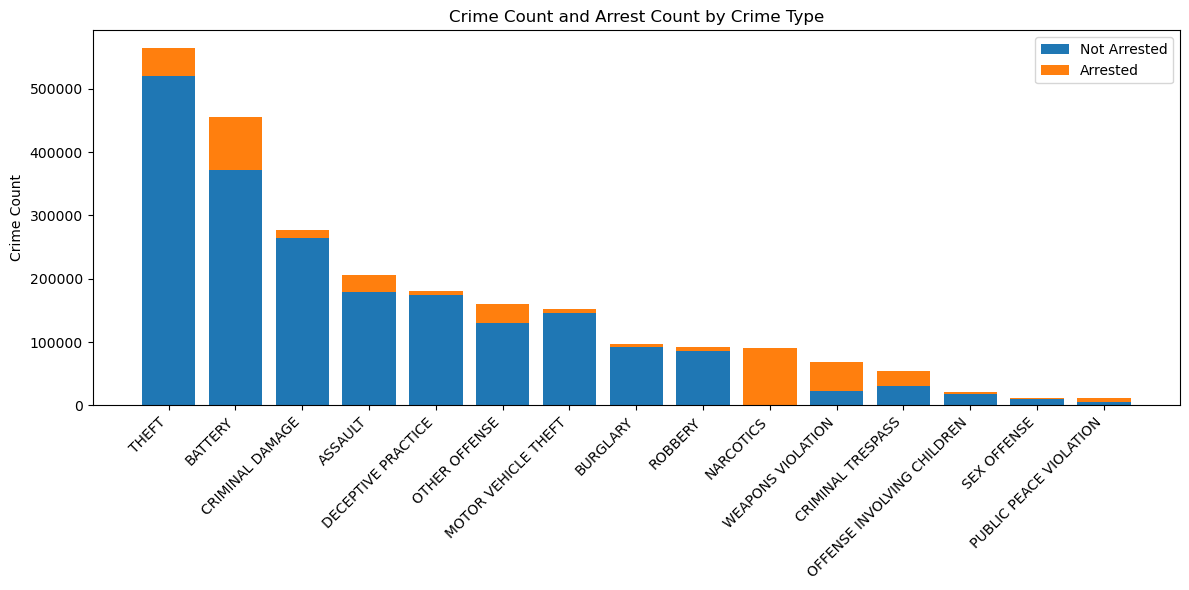

In [166]:


plt.figure(figsize=(12,6))

plt.bar(summary.index, summary['Not Arrested'], label='Not Arrested')
plt.bar(summary.index, summary['Arrested'],
        bottom=summary['Not Arrested'], label='Arrested')

plt.xticks(rotation=45, ha='right')
plt.ylabel('Crime Count')
plt.title('Crime Count and Arrest Count by Crime Type')
plt.legend()

plt.tight_layout()
plt.show()

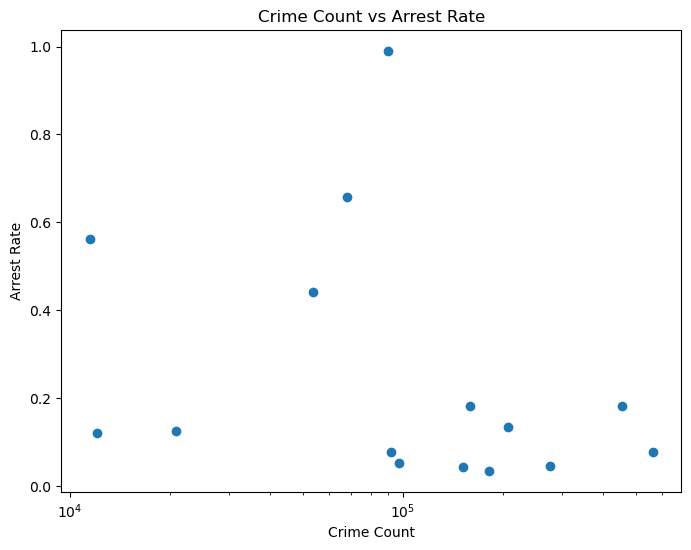

In [167]:
plt.figure(figsize=(8,6))
plt.scatter(summary['Total'], summary['Arrest Rate'])
plt.xlabel('Crime Count')
plt.ylabel('Arrest Rate')
plt.title('Crime Count vs Arrest Rate')
plt.xscale('log')
plt.show()

In [168]:
summary['Group'] = pd.qcut(summary['Total'], q=3, labels=['Low', 'Medium', 'High'])

group_stats = summary.groupby('Group')['Arrest Rate'].mean()

print(group_stats)

Group
Low       0.381207
Medium    0.268556
High      0.095046
Name: Arrest Rate, dtype: float64


/var/folders/y4/3yldd68d36qfw_vh1kk8kp5m0000gn/T/ipykernel_84683/1850957369.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = summary.groupby('Group')['Arrest Rate'].mean()


In [169]:
corr = summary['Total'].corr(summary['Arrest Rate'])
print("Correlation:", corr)

Correlation: -0.3378707414497341


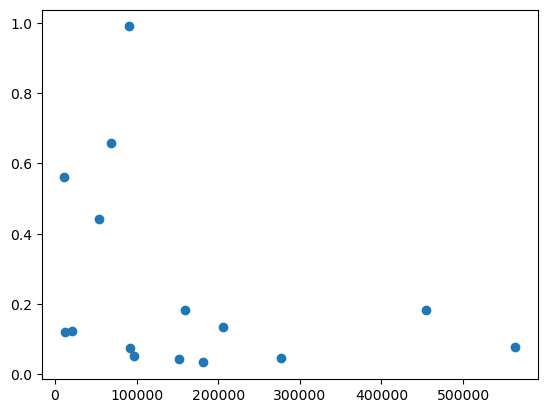

In [170]:
filtered = summary[summary['Total'] >= 1000]

plt.scatter(filtered['Total'], filtered['Arrest Rate'])

To examine the relationship between crime frequency and arrest outcomes, we analyze arrest rates across different crime types.

A clear inverse relationship is observed between crime count and arrest rate. As shown in the scatter plot (with log-scaled crime counts), crime types with lower frequencies tend to exhibit higher arrest rates, while high-frequency crimes generally have much lower arrest rates.

This pattern is further supported by grouping crime types into three categories based on their frequency (low, medium, high). The average arrest rates decrease consistently across these groups, from approximately 0.38 for low-frequency crimes to 0.27 for medium-frequency crimes, and down to 0.10 for high-frequency crimes. This monotonic trend indicates a systematic relationship rather than a random pattern.

To ensure that this relationship is not driven solely by small sample sizes, crime types with very low counts were filtered out (e.g., fewer than 1,000 incidents). The negative trend remains visible in the filtered scatter plot, suggesting that the inverse relationship is robust and not an artifact of rare crime categories.

In addition, the correlation coefficient between crime count and arrest rate is approximately -0.34, indicating a moderate negative association between these variables.

Overall, these results suggest that high-frequency crimes, such as theft and battery, are less likely to result in arrests, whereas less frequent crimes tend to have higher arrest rates. This pattern may reflect differences in detectability, enforcement strategies, and the nature of evidence associated with different crime types.

### 3.3 Arrest by Time

#### 3.3.1 Arrest by Hour

In [171]:
# Arrest by Hour
hour_summary = (
    df.groupby('Hour')
      .agg(
          Arrested=('Arrest', 'sum'),
          Total=('Arrest', 'size')
      )
)

hour_summary['Not Arrested'] = hour_summary['Total'] - hour_summary['Arrested']

hour_summary = hour_summary.sort_index()

print(hour_summary)

      Arrested   Total  Not Arrested
Hour                                
0        19468  155805        136337
1        13196   78672         65476
2        10284   68617         58333
3         7655   57755         50100
4         5437   46609         41172
5         4131   40686         36555
6         5613   45181         39568
7         7680   61069         53389
8        11331   85860         74529
9        14112  110613         96501
10       19170  110369         91199
11       22534  112265         89731
12       21832  148226        126394
13       19977  116942         96965
14       19820  122664        102844
15       21056  134746        113690
16       22461  132089        109628
17       21988  134340        112352
18       24360  135886        111526
19       28308  133246        104938
20       26173  127672        101499
21       23483  117926         94443
22       21709  114368         92659
23       19225  100062         80837


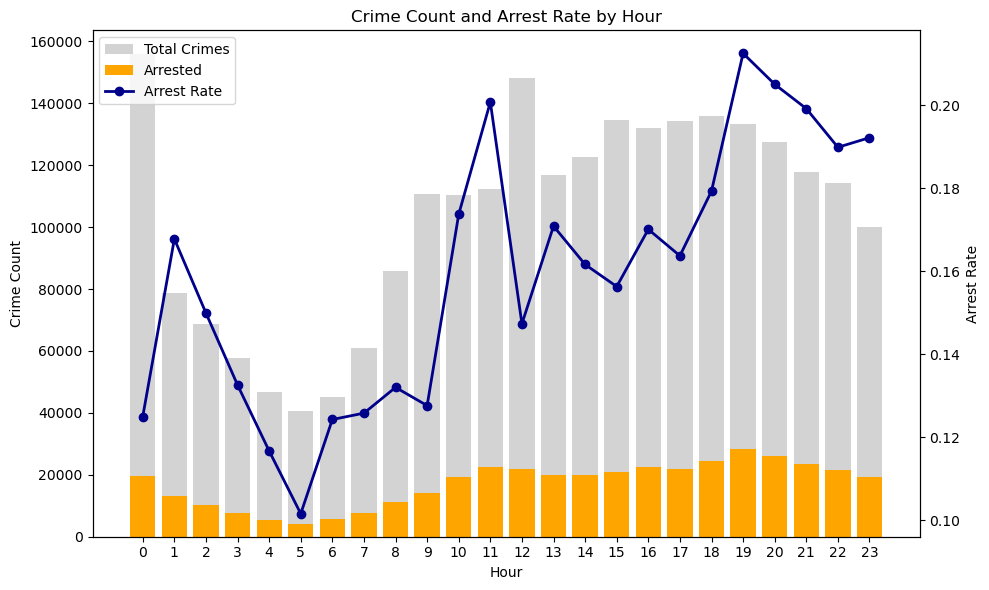

In [172]:
fig, ax1 = plt.subplots(figsize=(10,6))

# Total crimes
bars_total = ax1.bar(
    hour_summary.index,
    hour_summary['Total'],
    color='lightgray',
    label='Total Crimes'
)

#Arrested
bars_arrested = ax1.bar(
    hour_summary.index,
    hour_summary['Arrested'],
    color='orange',
    label='Arrested'
)

ax1.set_xlabel('Hour')
ax1.set_ylabel('Crime Count')
ax1.set_xticks(range(0, 24))


ax2 = ax1.twinx()
line_rate, = ax2.plot(
    hour_summary.index,
    hour_summary['Arrested'] / hour_summary['Total'],
    color='darkblue',
    marker='o',
    linewidth=2
)

ax2.set_ylabel('Arrest Rate')


ax1.legend(
    [bars_total, bars_arrested, line_rate],
    ['Total Crimes', 'Arrested', 'Arrest Rate'],
    loc='upper left'
)

plt.title('Crime Count and Arrest Rate by Hour')
plt.tight_layout()
plt.show()

#### 3.3.2 Arrest by Day of Week


In [173]:
day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

day_summary = (
    df.groupby('DayName')
      .agg(
          Total=('Arrest', 'size'),
          Arrested=('Arrest', 'sum')
      )
      .reindex(day_order)
)

print(day_summary)

          Total  Arrested
DayName                  
Mon      356112     57150
Tue      350160     57800
Wed      351983     58169
Thu      349319     57475
Fri      369755     61347
Sat      362076     60260
Sun      352263     58802


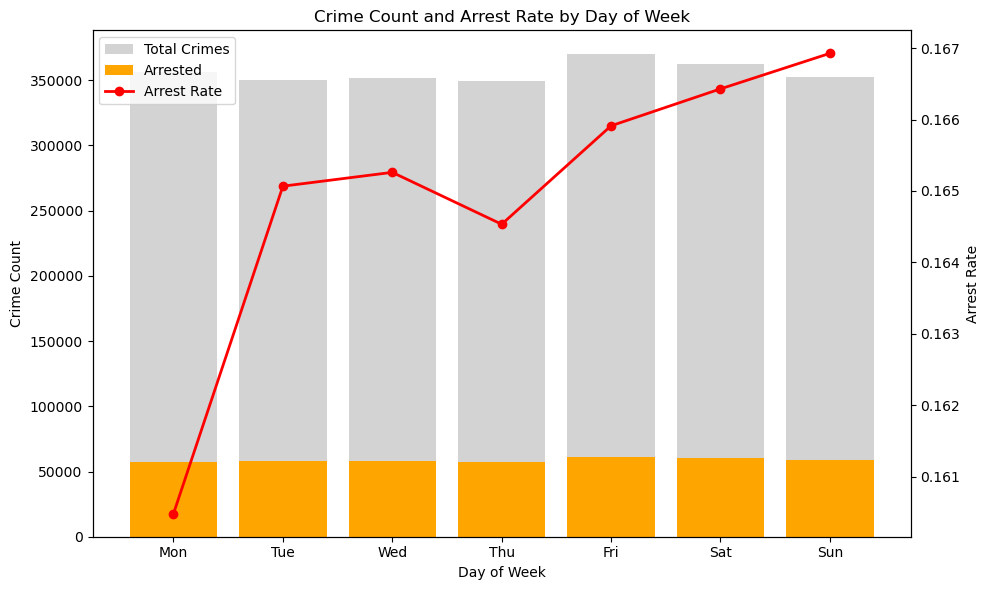

In [174]:
fig, ax1 = plt.subplots(figsize=(10,6))

#  Total
bars_total = ax1.bar(
    day_summary.index,
    day_summary['Total'],
    color='lightgray'
)

# Arrested
bars_arrested = ax1.bar(
    day_summary.index,
    day_summary['Arrested'],
    color='orange'
)

ax1.set_xlabel('Day of Week')
ax1.set_ylabel('Crime Count')

#  Arrest Rate
ax2 = ax1.twinx()
line_rate, = ax2.plot(
    day_summary.index,
    day_summary['Arrested'] / day_summary['Total'],
    color='red',
    marker='o',
    linewidth=2
)

ax2.set_ylabel('Arrest Rate')

#  legend
ax1.legend(
    [bars_total, bars_arrested, line_rate],
    ['Total Crimes', 'Arrested', 'Arrest Rate'],
    loc='upper left'
)

plt.title('Crime Count and Arrest Rate by Day of Week')
plt.tight_layout()
plt.show()

In [175]:
 # Weekday vs Weekend 
df['IsWeekend'] = df['DayOfWeek'].isin([5, 6])  # Sat=5, Sun=6
weekend_summary = (
    df.groupby('IsWeekend')
      .agg(
          Total=('Arrest', 'size'),
          Arrested=('Arrest', 'sum')
      )
      .reset_index()
)

weekend_summary['Type'] = weekend_summary['IsWeekend'].map({
    False: 'Weekday',
    True: 'Weekend'
})

print(weekend_summary)
 

   IsWeekend    Total  Arrested     Type
0      False  1777329    291941  Weekday
1       True   714339    119062  Weekend


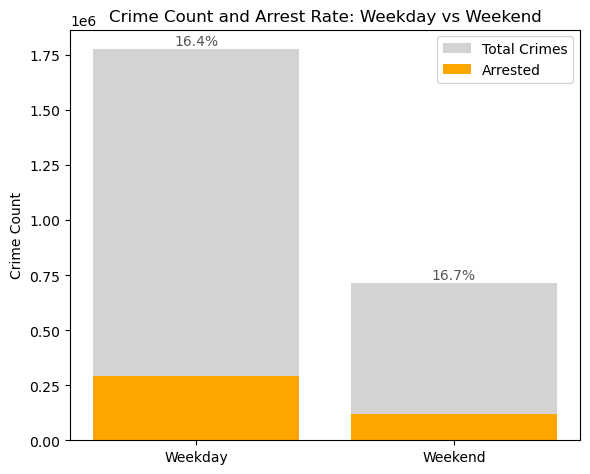

In [176]:
fig, ax1 = plt.subplots(figsize=(6,5))

# Total
bars_total = ax1.bar(
    weekend_summary['Type'],
    weekend_summary['Total'],
    color='lightgray'
)

# Arrested（覆盖）
bars_arrested = ax1.bar(
    weekend_summary['Type'],
    weekend_summary['Arrested'],
    color='orange'
)

ax1.set_ylabel('Crime Count')

# ⭐ 在柱子上标 arrest rate
rates = weekend_summary['Arrested'] / weekend_summary['Total']
offset = weekend_summary['Total'].max() * 0.01
for i, rate in enumerate(rates):
    ax1.text(
        i,
        weekend_summary['Total'].iloc[i] + offset,   # 更靠近顶部
        f'{rate*100:.1f}%',                       # 百分数
        ha='center',
        color='#555555',                          # 更柔和
        fontsize=10
    )

# legend
ax1.legend(
    [bars_total, bars_arrested],
    ['Total Crimes', 'Arrested'],
    loc='upper right'
)

plt.title('Crime Count and Arrest Rate: Weekday vs Weekend')

plt.tight_layout()
plt.show()

#### 3.3.3 Interaction（Hour × Day）

In [ ]:
crime_pivot = df.pivot_table(
    index='DayName',
    columns='Hour',
    values='ID',
    aggfunc='count'
)

order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
crime_pivot = crime_pivot.reindex(order)
crime_pivot = crime_pivot.apply(pd.to_numeric, errors='coerce')
crime_pivot = crime_pivot.astype(float)

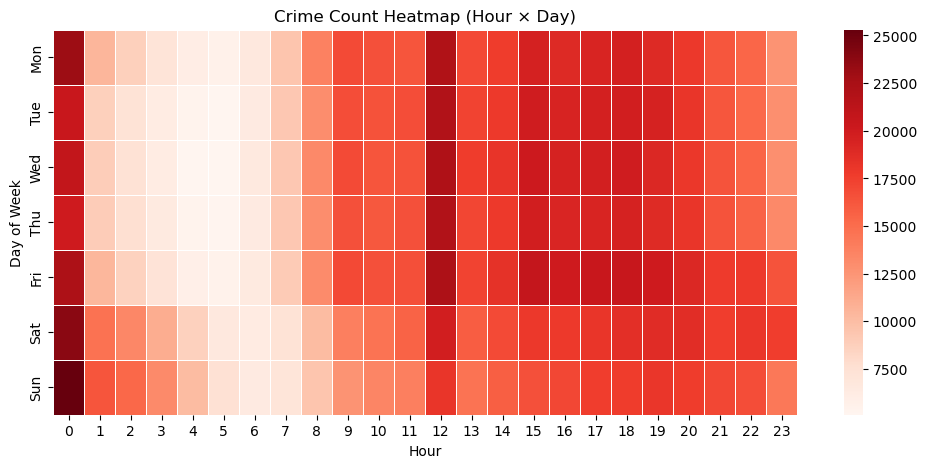

In [189]:
plt.figure(figsize=(12,5))
sns.heatmap(
    crime_pivot,
    cmap='Reds',
    linewidths=0.5
)

plt.title('Crime Count Heatmap (Hour × Day)')
plt.xlabel('Hour')
plt.ylabel('Day of Week')
plt.show()

In [192]:
arrest_pivot = df.pivot_table(
    index='DayName',
    columns='Hour',
    values='Arrest',
    aggfunc='mean'
)

arrest_pivot = arrest_pivot.reindex(order)

arrest_pivot = arrest_pivot.apply(pd.to_numeric, errors='coerce')
arrest_pivot = arrest_pivot.astype(float)

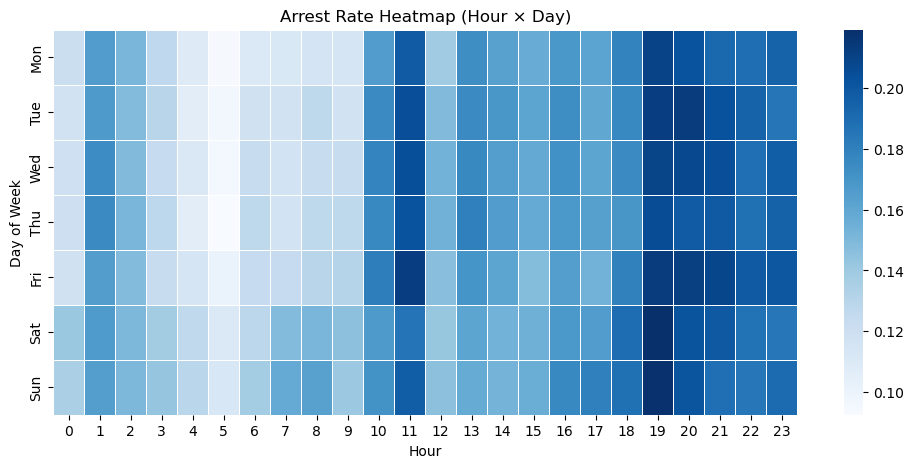

In [193]:
plt.figure(figsize=(12,5))
sns.heatmap(
    arrest_pivot,
    cmap='Blues',
    linewidths=0.5
)

plt.title('Arrest Rate Heatmap (Hour × Day)')
plt.xlabel('Hour')
plt.ylabel('Day of Week')
plt.show()

The interaction between hour of day and day of week reveals more nuanced crime patterns. 
Crime incidents are consistently higher during afternoon and evening hours across all days, with a noticeable peak around midday, which may reflect potential data recording artifacts.

While variation across days of the week is relatively limited, weekends exhibit slightly higher crime levels overall.

Arrest rates also display clear temporal variation. Higher arrest rates are observed during evening hours, whereas early morning periods tend to have lower arrest rates. 

Importantly, certain time windows, particularly early morning hours, exhibit relatively lower arrest rates despite moderate crime levels, suggesting potential gaps in enforcement effectiveness during these periods.

#### 3.3.4 Arrest by Month

In [194]:
monthly_summary = (
    df.groupby('Month')
    .agg(
        Total=('Arrest', 'size'),
        Arrested=('Arrest', 'sum')
    )
    .reset_index()
)

monthly_summary['Arrest Rate'] = (
    monthly_summary['Arrested'] / monthly_summary['Total']
)

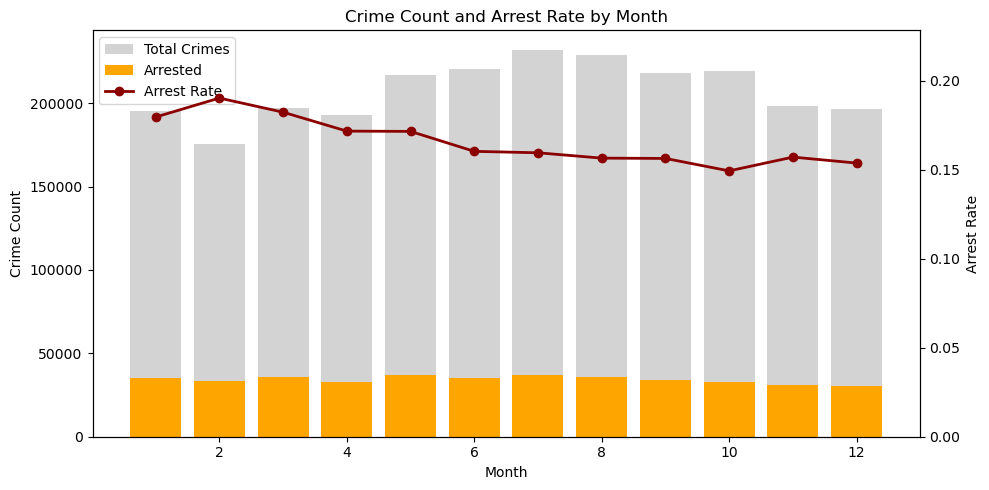

In [196]:
fig, ax1 = plt.subplots(figsize=(10,5))

# ===== 左轴：Crime Count =====
bars_total = ax1.bar(
    monthly_summary['Month'],
    monthly_summary['Total'],
    color='lightgray',
    label='Total Crimes'
)

bars_arrested = ax1.bar(
    monthly_summary['Month'],
    monthly_summary['Arrested'],
    color='orange',
    label='Arrested'
)

ax1.set_xlabel('Month')
ax1.set_ylabel('Crime Count')

# ===== 右轴：Arrest Rate =====
ax2 = ax1.twinx()

line_rate, = ax2.plot(
    monthly_summary['Month'],
    monthly_summary['Arrest Rate'],
    color='darkred',
    marker='o',
    linewidth=2,
    label='Arrest Rate'
)

ax2.set_ylabel('Arrest Rate')

# 👉 控制一下范围（很关键，看起来更清晰）
ax2.set_ylim(0, monthly_summary['Arrest Rate'].max() * 1.2)

# ===== 合并图例（关键！！！）=====
ax1.legend(
    [bars_total, bars_arrested, line_rate],
    ['Total Crimes', 'Arrested', 'Arrest Rate'],
    loc='upper left'
)

plt.title('Crime Count and Arrest Rate by Month')

plt.tight_layout()
plt.show()

The monthly arrest pattern differs from the monthly crime volume pattern. While the number of crimes peaks in summer, arrest rates are highest in January and February and gradually decline through the middle of the year, reaching their lowest levels in October before a modest rebound in late fall and winter.

This divergence suggests that periods with more crime do not necessarily correspond to higher arrest probabilities. Seasonal increases in crime may be driven by offenses that are more difficult to solve immediately, while colder months may involve incident types or enforcement conditions associated with relatively higher arrest likelihood.

For predictive modeling, this result implies that month should not be treated only as a proxy for crime volume; it may also capture systematic variation in the conditional probability of arrest.


## 3.4 Arrest Patterns by Space and Setting

Because the project focuses on predicting arrest outcomes, it is important to examine not only when crimes occur, but also where they occur. District, community area, and location description capture different levels of spatial and situational context and may provide substantial predictive signal.


### 3.4.1 Arrest Patterns by Location Description


In [ ]:
location_summary = (
    df.groupby('Location Description')
      .agg(
          Total=('Arrest', 'size'),
          ArrestRate=('Arrest', 'mean')
      )
      .reset_index()
      .sort_values('Total', ascending=False)
)

location_top12 = location_summary.head(12).copy()
location_rate_top = (
    location_summary[location_summary['Total'] >= 10000]
    .sort_values('ArrestRate', ascending=False)
    .head(10)
    .sort_values('ArrestRate')
)

print(location_top12)
print(location_rate_top)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=location_top12.sort_values('Total'),
    x='Total',
    y='Location Description',
    color='steelblue',
    ax=axes[0]
)
axes[0].set_title('Top 12 Location Types by Crime Count')
axes[0].set_xlabel('Crime Count')
axes[0].set_ylabel('Location Description')

sns.barplot(
    data=location_rate_top,
    x='ArrestRate',
    y='Location Description',
    color='darkorange',
    ax=axes[1]
)
axes[1].set_title('Highest Arrest Rates by Location Type (>=10,000 crimes)')
axes[1].set_xlabel('Arrest Rate')
axes[1].set_ylabel('Location Description')

plt.tight_layout()
plt.show()


Location context is strongly associated with arrest outcomes. Street incidents account for the largest number of crimes and have an arrest rate slightly above the overall average, but several commercial and public-facing locations show much higher arrest rates. In particular, grocery stores, department stores, sidewalks, alleys, and gas stations all exhibit relatively high arrest probabilities.

By contrast, residential settings such as apartments, residences, and garages have noticeably lower arrest rates. This may reflect differences in witness availability, surveillance, offender-civilian interaction, or the extent to which incidents are discovered after the fact rather than during the event.

These findings suggest that location description is likely to be an informative feature for arrest prediction because it captures situational visibility and enforcement opportunity beyond broad geography alone.


### 3.4.2 Arrest Patterns by Police District


In [ ]:
district_summary = (
    df.groupby('District')
      .agg(
          Total=('Arrest', 'size'),
          ArrestRate=('Arrest', 'mean')
      )
      .dropna()
      .reset_index()
)

district_top_count = district_summary.sort_values('Total', ascending=False).head(12)
district_top_rate = (
    district_summary[district_summary['Total'] >= 10000]
    .sort_values('ArrestRate', ascending=False)
    .head(10)
    .sort_values('ArrestRate')
)

print(district_top_count)
print(district_top_rate)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(
    data=district_top_count.sort_values('Total'),
    x='Total',
    y='District',
    color='slateblue',
    ax=axes[0]
)
axes[0].set_title('Top Police Districts by Crime Count')
axes[0].set_xlabel('Crime Count')
axes[0].set_ylabel('District')

sns.barplot(
    data=district_top_rate,
    x='ArrestRate',
    y='District',
    color='seagreen',
    ax=axes[1]
)
axes[1].set_title('Highest Arrest Rates by District (>=10,000 crimes)')
axes[1].set_xlabel('Arrest Rate')
axes[1].set_ylabel('District')

plt.tight_layout()
plt.show()


District-level differences are substantial. Some of the highest-volume districts, such as District 11, also have unusually high arrest rates, while others with similar crime volume show much lower rates. This indicates that spatial variation in arrest outcomes is not simply a consequence of crime frequency.

The district analysis supports the project proposal's emphasis on spatial predictors. District may summarize differences in policing patterns, land use, neighborhood composition, and case mix that are not fully captured by offense type or time variables.


### 3.4.3 Arrest Patterns by Community Area


In [ ]:
community_summary = (
    df.groupby('Community Area')
      .agg(
          Total=('Arrest', 'size'),
          ArrestRate=('Arrest', 'mean')
      )
      .dropna()
      .reset_index()
)

community_top_rate = (
    community_summary[community_summary['Total'] >= 10000]
    .sort_values('ArrestRate', ascending=False)
    .head(10)
    .sort_values('ArrestRate')
)

community_bottom_rate = (
    community_summary[community_summary['Total'] >= 10000]
    .sort_values('ArrestRate', ascending=True)
    .head(10)
    .sort_values('ArrestRate')
)

print(community_top_rate)
print(community_bottom_rate)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(
    data=community_top_rate,
    x='ArrestRate',
    y='Community Area',
    color='teal',
    ax=axes[0]
)
axes[0].set_title('Highest Arrest Rates by Community Area (>=10,000 crimes)')
axes[0].set_xlabel('Arrest Rate')
axes[0].set_ylabel('Community Area')

sns.barplot(
    data=community_bottom_rate,
    x='ArrestRate',
    y='Community Area',
    color='indianred',
    ax=axes[1]
)
axes[1].set_title('Lowest Arrest Rates by Community Area (>=10,000 crimes)')
axes[1].set_xlabel('Arrest Rate')
axes[1].set_ylabel('Community Area')

plt.tight_layout()
plt.show()


Community-area variation is even more pronounced than district variation. Several community areas have arrest rates above 25% or even 30%, while others remain below 10% despite having substantial crime counts.

This gap suggests that finer geographic granularity may improve predictive performance beyond district-level indicators. It also provides an empirical basis for later interpretability analysis, since geographic features may emerge as important contributors in the final model.


## 3.5 Arrest Patterns Over Time

The project proposal specifies out-of-time validation, so it is useful to inspect whether arrest outcomes are stable across years. If arrest rates shift materially over time, a model trained on earlier years may face distributional change when evaluated on later years.


In [ ]:
year_summary = (
    df.groupby('Year')
      .agg(
          Total=('Arrest', 'size'),
          Arrested=('Arrest', 'sum')
      )
      .reset_index()
      .sort_values('Year')
)

year_summary['ArrestRate'] = year_summary['Arrested'] / year_summary['Total']
print(year_summary)


In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 5))

bars = ax1.bar(year_summary['Year'], year_summary['Total'], color='lightgray', label='Total Crimes')
ax1.set_xlabel('Year')
ax1.set_ylabel('Crime Count')
ax1.set_xticks(year_summary['Year'])

ax2 = ax1.twinx()
line_rate, = ax2.plot(
    year_summary['Year'],
    year_summary['ArrestRate'],
    color='crimson',
    marker='o',
    linewidth=2,
    label='Arrest Rate'
)
ax2.set_ylabel('Arrest Rate')

ax1.legend([bars, line_rate], ['Total Crimes', 'Arrest Rate'], loc='upper right')
plt.title('Crime Count and Arrest Rate by Year')
plt.tight_layout()
plt.show()


Arrest rates are not temporally stable. They are relatively high from 2016 to 2019, decline sharply from 2020 onward, and only partially recover in 2024 and 2025. This pattern is important because it indicates that later-year arrest outcomes are generated under different conditions than those observed in the pre-2020 period.

This finding directly supports the use of out-of-time validation in the modeling phase. A random train-test split would likely overstate model performance by mixing together records from periods with different arrest regimes, whereas year-based splitting better reflects the real forecasting setting.


## 3.6 EDA Summary for Modeling

The exploratory analysis shows that arrest outcomes vary systematically across multiple dimensions. Crime type produces some of the strongest differences in arrest probability, but temporal variables such as year, month, hour, and day of week also matter. Spatial and situational features, especially district, community area, and location description, add another clear layer of signal.

Taken together, these results support the feature design proposed in the project approval form. Temporal, categorical, and spatial variables all appear relevant for predicting arrest outcomes, and the substantial year-to-year variation further justifies an out-of-time evaluation framework. In the modeling stage, these EDA findings can guide both baseline statistical models and more flexible ensemble methods, while later SHAP analysis can be used to confirm which of these variables contribute most strongly to prediction.
